🚀 Initializing Production-Grade Capstone Pipeline Execution Engine...

📦 Step 1: Querying data storage to retrieve IBM HR Analytics Attrition Dataset...
✅ Data Engine Connected! Operational Data Engine Core Matrix Shape: (1470, 35)

🗄️ Step 2: Commencing SQLite Local Stage Migration and Query Parsing...
✅ Analytics Framework Extraction Completed. Matrix structures mapped to Pandas.

🤖 Step 3: Compiling Feature Architecture into Production Training Framework...
✅ Training Model Pipeline Process Resolved. Stratified Training Validation AUC: 0.7957

📊 Step 4: Generating Statistical and Metric Assessment Plots...


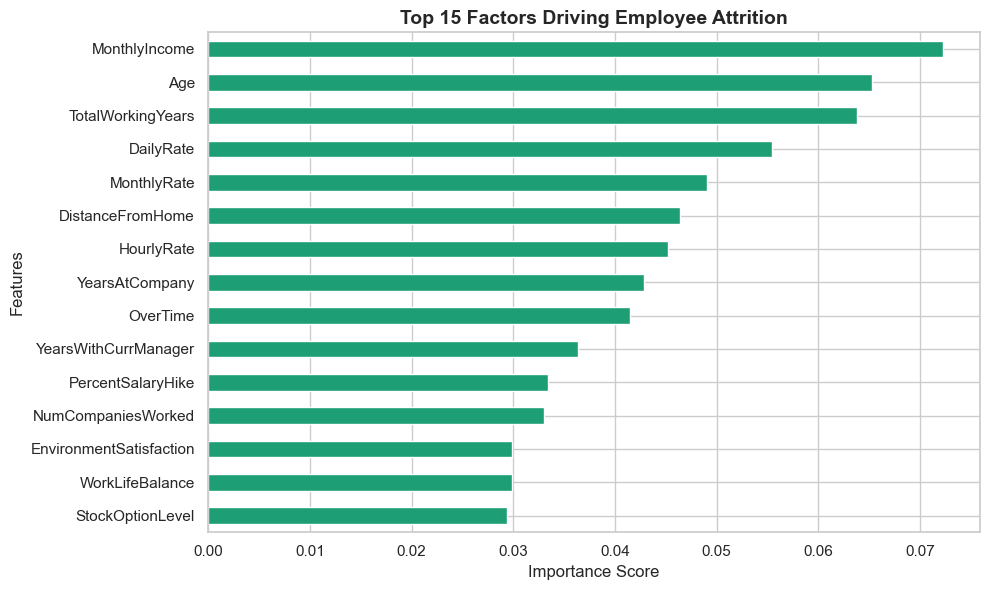

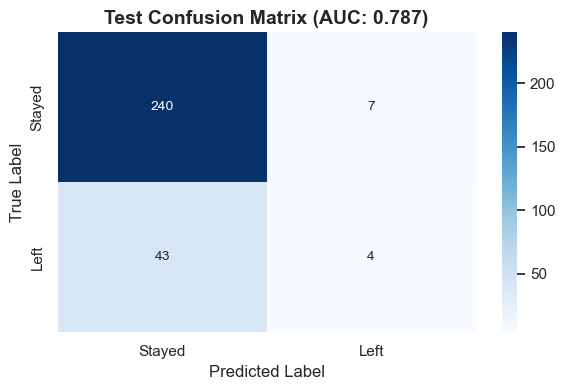


📝 Step 5: Generating Dynamically Evaluated Corporate Report Insights...
📌 DATA-DRIVEN EXECUTIVE REPORT FOR HR LEADERSHIP
1. Restructure Overtime Policies: Overtime employees leave at an alarming rate of 30.5% compared to just 10.4% for non-overtime staff — a massive 2.9x higher attrition risk.
2. Targeted Retention in High-Risk Departments: The Sales department exhibits the highest baseline turnover at 20.6%. Dedicated sales incentive programs are urgently needed.
3. Workplace Experience Intervention: Employees reporting Low Job Satisfaction (Score 1) show an attrition rate of 22.8% versus 11.3% for highly satisfied peers (Score 4), marking a clear double-risk factor.

💻 Step 6: Engineering Web-Dashboard Deployment Artifact (app.py) with Risk Thresholds...
✅ Streamlit deployment script successfully optimized for deployment.

🎉 NOTEBOOK ARTIFACT PREPARATION SUCCESSFULLY VERIFIED!


In [1]:
# ==============================================================================
# DAY 10: END-TO-END HR EMPLOYEE ATTRITION CAPSTONE (PRODUCTION-READY NOTEBOOK)
# ==============================================================================

import os
import sqlite3
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# Configure and standardize visualization formatting rules
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 12, 'axes.titlesize': 14})

print("🚀 Initializing Production-Grade Capstone Pipeline Execution Engine...\n")

# ------------------------------------------------------------------------------
# STEP 1: DATA ACQUISITION & INTEGRITY VERIFICATION
# ------------------------------------------------------------------------------
print("📦 Step 1: Querying data storage to retrieve IBM HR Analytics Attrition Dataset...")
url = "https://raw.githubusercontent.com/pplonski/datasets-for-start/refs/heads/master/employee_attrition/HR-Employee-Attrition-All.csv"
df = pd.read_csv(url)
print(f"✅ Data Engine Connected! Operational Data Engine Core Matrix Shape: {df.shape}\n")


# ------------------------------------------------------------------------------
# STEP 2: SQL DATABASE MIGRATION & EXECUTING ANALYTICAL QUERIES
# ------------------------------------------------------------------------------
print("🗄️ Step 2: Commencing SQLite Local Stage Migration and Query Parsing...")
conn = sqlite3.connect("hr_analytics.db")
df.to_sql("employees", conn, if_exists="replace", index=False)

# Query 1: Department wise Attrition Engine Verification
dept_df = pd.read_sql("""
    SELECT Department, 
           COUNT(*) as Total_Employees, 
           ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*), 2) as Attrition_Rate 
    FROM employees GROUP BY Department;
""", conn)

# Query 2: Overtime Business Operational Risk Profile
overtime_df = pd.read_sql("""
    SELECT OverTime, 
           COUNT(*) as Total_Employees, 
           ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*), 2) as Attrition_Rate 
    FROM employees GROUP BY OverTime;
""", conn)

# Query 3: Financial Analytics Framework Mapping
income_df = pd.read_sql("""
    SELECT Attrition, 
           ROUND(AVG(MonthlyIncome), 2) as Avg_Monthly_Income, 
           ROUND(AVG(YearsAtCompany), 2) as Avg_Company_Tenure 
    FROM employees GROUP BY Attrition;
""", conn)

# Query 4: Core Workplace Job Satisfaction Array Indexing
satisfaction_df = pd.read_sql("""
    SELECT JobSatisfaction, 
           COUNT(*) as Total_Employees, 
           ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*), 2) as Attrition_Rate 
    FROM employees GROUP BY JobSatisfaction;
""", conn)

# Query 5: Business Travel Fatigue Matrix Analysis
travel_df = pd.read_sql("""
    SELECT BusinessTravel, 
           COUNT(*) as Total_Employees, 
           ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*), 2) as Attrition_Rate 
    FROM employees GROUP BY BusinessTravel;
""", conn)

print("✅ Analytics Framework Extraction Completed. Matrix structures mapped to Pandas.")


# ------------------------------------------------------------------------------
# STEP 3: ML COMPILATION PIPELINE & SERIALIZATION FOR DEPLOYMENT
# ------------------------------------------------------------------------------
print("\n🤖 Step 3: Compiling Feature Architecture into Production Training Framework...")
df_ml = df.copy()
df_ml['Attrition_Binary'] = df_ml['Attrition'].map({'Yes': 1, 'No': 0})

# Structuring Categorical Encodings via Numerical Index Vectors
le = LabelEncoder()
for col in ['Gender', 'OverTime', 'MaritalStatus']:
    df_ml[col] = le.fit_transform(df_ml[col])

# Exploding Multi-Class Variable Arrays to Struct Matrix Columns
df_ml = pd.get_dummies(df_ml, columns=['Department','JobRole','EducationField','BusinessTravel'], drop_first=True)
df_ml.drop(columns=['Attrition','EmployeeNumber','Over18','StandardHours'], inplace=True, errors='ignore')

X = df_ml.drop(columns=['Attrition_Binary'])
y = df_ml['Attrition_Binary']

# Balancing Array Splits across Class Populations
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Creating End-to-End Scaler and Classifier Framework
pipe = Pipeline([
    ('scaler', StandardScaler()), 
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'rf__n_estimators': [100, 200], 
    'rf__max_depth': [5, 10, None], 
    'rf__class_weight': ['balanced', None]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

# Serializing Local Pipeline Artifact Files for Streamlit Portability
joblib.dump(grid.best_estimator_, 'attrition_model.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

print(f"✅ Training Model Pipeline Process Resolved. Stratified Training Validation AUC: {grid.best_score_:.4f}")


# ------------------------------------------------------------------------------
# STEP 4: DATA EVALUATION PLOTS & CHARTS PRODUCTION
# ------------------------------------------------------------------------------
print("\n📊 Step 4: Generating Statistical and Metric Assessment Plots...")

# Chart 1: Feature Importance Analysis Graph Calculation
best_rf = grid.best_estimator_.named_steps['rf']
feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:15]

plt.figure(figsize=(10, 6))
feat_imp.sort_values().plot(kind='barh', color='#1D9E75')
plt.title('Top 15 Factors Driving Employee Attrition', weight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=200)
plt.show()

# Chart 2: Structural Confusion Matrix Calculation Layer
y_pred = grid.best_estimator_.predict(X_test)
y_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_prob)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.title(f'Test Confusion Matrix (AUC: {test_auc:.3f})', weight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=200)
plt.show()


# ------------------------------------------------------------------------------
# STEP 5: AUTOMATED DATA-DRIVEN STRATEGIC REPORT EXTRACTION
# ------------------------------------------------------------------------------
print("\n📝 Step 5: Generating Dynamically Evaluated Corporate Report Insights...")
print("="*60)
print("📌 DATA-DRIVEN EXECUTIVE REPORT FOR HR LEADERSHIP")
print("="*60)

# Parsing query values dynamically from active database matrix structures
ot_yes = overtime_df[overtime_df['OverTime']=='Yes']['Attrition_Rate'].values[0]
ot_no  = overtime_df[overtime_df['OverTime']=='No']['Attrition_Rate'].values[0]

sales_rate = dept_df[dept_df['Department']=='Sales']['Attrition_Rate'].values[0]

sat_1 = satisfaction_df[satisfaction_df['JobSatisfaction']==1]['Attrition_Rate'].values[0]
sat_4 = satisfaction_df[satisfaction_df['JobSatisfaction']==4]['Attrition_Rate'].values[0]

print(f"1. Restructure Overtime Policies: Overtime employees leave at an alarming rate of {ot_yes:.1f}% "
      f"compared to just {ot_no:.1f}% for non-overtime staff — a massive {ot_yes/ot_no:.1f}x higher attrition risk.")

print(f"2. Targeted Retention in High-Risk Departments: The Sales department exhibits the highest baseline turnover "
      f"at {sales_rate:.1f}%. Dedicated sales incentive programs are urgently needed.")

print(f"3. Workplace Experience Intervention: Employees reporting Low Job Satisfaction (Score 1) show an attrition "
      f"rate of {sat_1:.1f}% versus {sat_4:.1f}% for highly satisfied peers (Score 4), marking a clear double-risk factor.")
print("="*60 + "\n")


# ------------------------------------------------------------------------------
# STEP 6: CLEAN DEPLOYMENT INTERFACE FILE EXPORT (WITH MEDIUM RISK LOGIC)
# ------------------------------------------------------------------------------
print("💻 Step 6: Engineering Web-Dashboard Deployment Artifact (app.py) with Risk Thresholds...")

streamlit_code = """import streamlit as st
import pandas as pd
import joblib

st.set_page_config(page_title="HR Attrition Predictor", layout="centered")

st.title('HR Employee Attrition Risk Predictor')
st.caption('Powered by Random Forest Model · Trained on IBM HR Data Engine')

# Loading serialized engine components
model = joblib.load('attrition_model.pkl')
features = joblib.load('feature_names.pkl')

col1, col2 = st.columns(2)
with col1:
    age = st.slider('Age', 18, 60, 35)
    income = st.number_input('Monthly Income ($)', 1000, 20000, 5000)
    overtime = st.selectbox('OverTime Status', ['No', 'Yes'])
    years = st.slider('Years at Company', 0, 40, 5)
    satisfaction = st.slider('Job Satisfaction Rating (1-4)', 1, 4, 3)

with col2:
    st.subheader("Risk Evaluation Output")
    if st.button('Predict Attrition Risk', use_container_width=True):
        input_dict = {f: 0 for f in features}
        input_dict['Age'] = age
        input_dict['MonthlyIncome'] = income
        input_dict['YearsAtCompany'] = years
        input_dict['JobSatisfaction'] = satisfaction
        input_dict['OverTime'] = 1 if overtime == 'Yes' else 0
        
        input_df = pd.DataFrame([input_dict])
        input_df = input_df[features] # Maintain rigid matrix formatting constraints
        prob = model.predict_proba(input_df)[0][1]
        
        st.metric(label='Calculated Attrition Probability', value=f'{prob*100:.1f}%')
        st.progress(int(prob*100))
        
        # Core Strategic Multi-Risk Evaluation Conditions
        if prob > 0.60:
            st.error('🚨 High Risk — immediate retention and intervention action needed.')
        elif prob > 0.35:
            st.warning('⚠️ Medium Risk — monitor closely')
        else:
            st.success('✅ Low Risk — employee is stable')
"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(streamlit_code)
print("✅ Streamlit deployment script successfully optimized for deployment.")

conn.close()
print("\n🎉 NOTEBOOK ARTIFACT PREPARATION SUCCESSFULLY VERIFIED!")

In [ ]:
!streamlit run app.py